### Imports

In [1]:
import numpy as np
import pyproj as proj
import timeit
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from shapely.geometry import MultiPoint, Point, Polygon

from whale_gunshot_localization.utils.experimental import MultilaterationOpt, Localizer, ParLocalizer
import whale_gunshot_localization.sim_tools.sim_datagen as sim_datagen
from whale_gunshot_localization import config, PROJECT_ROOT_DIR

In [2]:
# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0])
TOSSIT_locations = np.asarray([-ys, xs]).T

In [3]:
TOSSIT_locations = np.asarray([TOSSIT_locations[:,1], -TOSSIT_locations[:,0]])

In [6]:
TOSSIT_locations.shape

(2, 17)

In [23]:
G = sim_datagen.PointsInPoly(TOSSIT_locations)
points = G.generate(100)
points.shape

(100, 2)

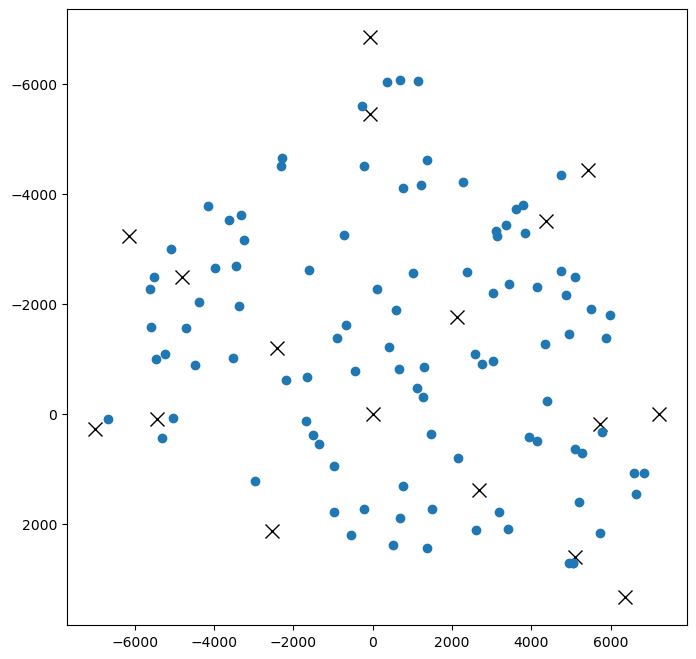

In [24]:
plt.plot(TOSSIT_locations[:,1], TOSSIT_locations[:,0], 'kx', markersize=10, label="TOSSIT")
plt.plot(points[:,1], points[:,0], 'o')
plt.gca().invert_yaxis()

### Generate Data

In [2]:
# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0])
TOSSIT_locations = np.asarray([-ys, xs]).T

data_gen_params = dict(num_delete=0, 
                       rng=np.random.default_rng(1234), 
                       in_sensors=True,
                       TOSSIT_locations=TOSSIT_locations)

measurements, source_associations, TOSSIT_associations, source_locs = sim_datagen.generate_measurements(num_sources=2, 
                                                                                                        var=0, 
                                                                                                        **data_gen_params)

In [3]:
L = ParLocalizer(k=4, multilat=MultilaterationOpt(method_thresh=float('inf')), consistency_thresh=50, TOSSIT_locations=TOSSIT_locations, min_assoc_size=4)

In [4]:
success = L.set_measurements(measurements)

True


In [5]:
assocs, loc = L.associate_and_localize(last_step=True)